<a href="https://colab.research.google.com/github/varunrao-24/Explainable-Multimodal-Ensemble-Learning-for-Skin-Lesion-Diagnosis/blob/main/Ensemble_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Step 1: Mount Google Drive and Load Data


from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import os
import cv2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns


base_path = "/content/drive/MyDrive/PAD-UFES-20"
data_path = os.path.join(base_path, "metadata.csv")
df = pd.read_csv(data_path)

print("Dataset Loaded Successfully")
df.head()

os.listdir(base_path)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset Loaded Successfully


['metadata.csv', 'imgs_part_3', 'imgs_part_1', 'imgs_part_2']

In [ ]:
!mkdir -p /content/drive/MyDrive/checkpoints


In [ ]:
# Step-2: Data Understanding
print("Shape of Dataset:", df.shape)
print("\nColumns:\n", df.columns)
print("\nMissing Values:\n", df.isnull().sum())
df.info()


Shape of Dataset: (2298, 26)

Columns:
 Index(['patient_id', 'lesion_id', 'smoke', 'drink', 'background_father',
       'background_mother', 'age', 'pesticide', 'gender',
       'skin_cancer_history', 'cancer_history', 'has_piped_water',
       'has_sewage_system', 'fitspatrick', 'region', 'diameter_1',
       'diameter_2', 'diagnostic', 'itch', 'grew', 'hurt', 'changed', 'bleed',
       'elevation', 'img_id', 'biopsed'],
      dtype='object')

Missing Values:
 patient_id               0
lesion_id                0
smoke                  804
drink                  804
background_father      818
background_mother      822
age                      0
pesticide              804
gender                 804
skin_cancer_history    804
cancer_history         804
has_piped_water        804
has_sewage_system      804
fitspatrick            804
region                   0
diameter_1             804
diameter_2             804
diagnostic               0
itch                     0
grew                 

In [ ]:
# Step-3: Handling Missing Values

# Fill numeric missing values with column mean
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

# Fill categorical missing values with mode
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print(df.isnull().sum().sum())
print("Missing values handled successfully!")


0
Missing values handled successfully!


/tmp/ipython-input-1768503459.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])


In [ ]:
# ===== Step 4: Encode categorical / boolean-like features =====

from sklearn.preprocessing import LabelEncoder

cat_cols_to_encode = [
    'smoke', 'drink', 'background_father', 'background_mother',
    'pesticide', 'gender', 'skin_cancer_history', 'cancer_history',
    'has_piped_water', 'has_sewage_system', 'fitspatrick', 'region',
    'itch', 'grew', 'hurt', 'changed', 'bleed',
    'elevation', 'biopsed'
]

cat_cols_to_encode = [col for col in cat_cols_to_encode if col in df.columns]
le_dict = {}
for col in cat_cols_to_encode:
    le = LabelEncoder()
    df[col] = df[col].astype(str)
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le

print("✅ Feature categorical columns encoded successfully!")
print("Encoded feature columns:", cat_cols_to_encode)

y_raw = df['diagnostic'].astype(str)
target_le = LabelEncoder()
y = target_le.fit_transform(y_raw)   # use 'y' as labels for training

print("Target classes:", target_le.classes_)
df_features = df.drop(columns=['diagnostic'])

# drop identifiers from features
df_features = df_features.drop(columns=['patient_id', 'lesion_id', 'img_id'], errors='ignore')
print("✅ Identifier columns removed successfully from features!")

✅ Feature categorical columns encoded successfully!
Encoded feature columns: ['smoke', 'drink', 'background_father', 'background_mother', 'pesticide', 'gender', 'skin_cancer_history', 'cancer_history', 'has_piped_water', 'has_sewage_system', 'fitspatrick', 'region', 'itch', 'grew', 'hurt', 'changed', 'bleed', 'elevation', 'biopsed']
Target classes: ['ACK' 'BCC' 'MEL' 'NEV' 'SCC' 'SEK']
✅ Identifier columns removed successfully from features!


In [ ]:
# ===== Step 5: Normalize numeric feature columns (not labels) =====
from sklearn.preprocessing import StandardScaler

exclude_cols = ['image_path']

numeric_feature_cols = [
    col for col in df_features.select_dtypes(include=['float64', 'int64']).columns
    if col not in exclude_cols
]

df_features[numeric_feature_cols] = df_features[numeric_feature_cols].fillna(
    df_features[numeric_feature_cols].mean()
)

scaler = StandardScaler()
df_features[numeric_feature_cols] = scaler.fit_transform(df_features[numeric_feature_cols])

print("Mean of numeric feature cols (should be ~0):")
print(df_features[numeric_feature_cols].mean())
print("\nStd of numeric feature cols (should be ~1):")
print(df_features[numeric_feature_cols].std())
print("✅ Numerical feature columns normalized successfully!")

Mean of numeric feature cols (should be ~0):
smoke                  3.169305e-17
drink                 -8.812214e-17
background_father     -1.236802e-16
background_mother     -1.004902e-16
age                   -2.133483e-16
pesticide             -1.375942e-16
gender                -6.184010e-18
skin_cancer_history    2.164403e-17
cancer_history        -4.019606e-17
has_piped_water        3.710406e-17
has_sewage_system     -9.276015e-17
fitspatrick           -1.159502e-16
region                 4.328807e-17
diameter_1            -9.894416e-17
diameter_2             1.886123e-16
itch                  -2.473604e-17
grew                   1.020362e-16
hurt                   7.111611e-17
changed                2.473604e-17
bleed                  7.111611e-17
elevation              1.035822e-16
biopsed                7.884613e-17
dtype: float64

Std of numeric feature cols (should be ~1):
smoke                  1.000218
drink                  1.000218
background_father      1.000218
backgro

In [ ]:
# STEP 6 — VERIFY IMAGE LINKS

import os
import glob
base_path = "/content/drive/MyDrive/PAD-UFES-20"

df_links = df.copy()
df_links["constructed_name"] = df_links["img_id"]

image_folders = [
    os.path.join(base_path, "imgs_part_1", "imgs_part_1"),
    os.path.join(base_path, "imgs_part_2", "imgs_part_2"),
    os.path.join(base_path, "imgs_part_3", "imgs_part_3")
]

all_images = []
for folder in image_folders:
    all_images.extend(glob.glob(os.path.join(folder, "*.png")))

image_dict = {os.path.basename(p): p for p in all_images}
df_links["image_path"] = df_links["constructed_name"].map(image_dict)


missing = df_links["image_path"].isna().sum()
print(f"🔍 Total rows: {len(df_links)}   |   Missing images: {missing}")


df_links = df_links.dropna(subset=["image_path"]).reset_index(drop=True)
df_links[["img_id", "image_path"]].head()
df['image_path'] = df_links['image_path']

print("🎯 Image paths successfully added to preprocessed dataframe!")
print("Final dataset shape:", df.shape)

df.head()



🔍 Total rows: 2298   |   Missing images: 0
🎯 Image paths successfully added to preprocessed dataframe!
Final dataset shape: (2298, 27)


,patient_id,lesion_id,smoke,drink,background_father,background_mother,age,pesticide,gender,skin_cancer_history,...,diagnostic,itch,grew,hurt,changed,bleed,elevation,img_id,biopsed,image_path
0,PAT_1516,1765,0,0,9,7,8,0,0,0,...,NEV,0,0,0,0,0,0,PAT_1516_1765_530.png,0,/content/drive/MyDrive/PAD-UFES-20/imgs_part_3...
1,PAT_46,881,0,0,9,7,55,0,0,1,...,BCC,1,1,0,1,1,1,PAT_46_881_939.png,1,/content/drive/MyDrive/PAD-UFES-20/imgs_part_1...
2,PAT_1545,1867,0,0,9,7,77,0,0,0,...,ACK,1,0,0,0,0,0,PAT_1545_1867_547.png,0,/content/drive/MyDrive/PAD-UFES-20/imgs_part_3...
3,PAT_1989,4061,0,0,9,7,75,0,0,0,...,ACK,1,0,0,0,0,0,PAT_1989_4061_934.png,0,/content/drive/MyDrive/PAD-UFES-20/imgs_part_3...
4,PAT_684,1302,0,1,9,7,79,0,1,1,...,BCC,1,1,0,0,1,1,PAT_684_1302_588.png,1,/content/drive/MyDrive/PAD-UFES-20/imgs_part_2...


In [ ]:
# STEP 7 — Train/Test Split (Multimodal Safe)

from sklearn.model_selection import train_test_split

target_col = 'diagnostic'
id_cols = ['patient_id', 'lesion_id']

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df[target_col]   # keeps class balance
)

print("Data successfully split!")
print(f"Training samples: {len(train_df)}")
print(f"Testing samples : {len(test_df)}")

feature_cols = [
    col for col in df.columns
    if col not in id_cols + [target_col, 'image_path']
]


X_train = train_df[feature_cols].values
X_test  = test_df[feature_cols].values

y_train = train_df[target_col].values
y_test  = test_df[target_col].values

train_image_paths = train_df['image_path'].values
test_image_paths  = test_df['image_path'].values

print("\n Shapes Check:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", len(y_train))
print("y_test :", len(y_test))


Data successfully split!
Training samples: 1838
Testing samples : 460

 Shapes Check:
X_train: (1838, 23)
X_test : (460, 23)
y_train: 1838
y_test : 460


In [ ]:
!ls /content/drive/MyDrive/PAD-UFES-20/imgs_part_1
!ls /content/drive/MyDrive/PAD-UFES-20/imgs_part_2
!ls /content/drive/MyDrive/PAD-UFES-20/imgs_part_3


In [ ]:
# UNIMODAL TABULAR STACKING ENSEMBLE (CLEAN)
# Used: SVM, GradientBoosting, ExtraTrees, LightGBM + LogisticRegression meta-model


import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.ensemble import GradientBoostingClassifier, ExtraTreesClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE

# 1. Define target and feature columns
target_col = "diagnostic"
id_cols = ["patient_id", "lesion_id", "img_id"]  # do NOT use as features
drop_cols = id_cols + ["image_path"]             # image_path also not a tabular feature

# Feature columns = everything except IDs, target, image_path
feature_cols = [c for c in df.columns if c not in drop_cols + [target_col]]

print("Feature columns used for tabular model:")
print(feature_cols)
print("Number of features:", len(feature_cols))

# 2. Build X, y from current cleaned df
X = df[feature_cols].values
y_raw = df[target_col].values   # e.g., ['NEV','BCC',...]

# Encode target labels to integers (needed for SMOTE, some models)
y_le = LabelEncoder()
y = y_le.fit_transform(y_raw)

print("Classes:", y_le.classes_)

# 3. Train / Test split (NO SMOTE here yet)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain size:", X_train.shape[0])
print("Test size :", X_test.shape[0])

# 4. Handle class imbalance with SMOTE ONLY on training data
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("After SMOTE, train size:", X_train_res.shape[0])
(unique, counts) = np.unique(y_train_res, return_counts=True)
print("Class counts after SMOTE:", dict(zip(y_le.inverse_transform(unique), counts)))

# 5. Define base models (same as your original code)
base_models = [
    ('svm', SVC(probability=True, kernel='rbf', C=1.5, gamma='scale')),
    ('gb', GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=5)),
    ('et', ExtraTreesClassifier(n_estimators=300, max_depth=None, random_state=42)),
    ('lgb', LGBMClassifier(n_estimators=300, learning_rate=0.05, max_depth=-1, random_state=42))
]

# 6. Define stacking ensemble
meta_model = LogisticRegression(max_iter=1000)
stack = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,
    n_jobs=-1
)

# 7. Train on oversampled training set
stack.fit(X_train_res, y_train_res)

# 8. Evaluate on untouched test set (true generalization)
y_pred = stack.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"\n✅ TRUE TEST ACCURACY (Tabular Only): {acc*100:.2f}%\n")

print("📊 Classification Report (Tabular Only):")
print(classification_report(y_test, y_pred, target_names=y_le.classes_))

print("🔢 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# 9. Optional: Cross-validation on the resampled training set (for stability)
cv_scores = cross_val_score(stack, X_train_res, y_train_res, cv=5, n_jobs=-1)
print(f"\n📈 Mean CV Accuracy on Training (SMOTE-resampled): {cv_scores.mean()*100:.2f}%")
print("CV scores:", (cv_scores * 100).round(2))

# 10. Optional: Feature importances from LightGBM base model
lgb_model = [m for n, m in base_models if n == 'lgb'][0]
lgb_model.fit(X_train_res, y_train_res)
importances = pd.Series(lgb_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("\n🔥 Top 10 Important Features (from LightGBM):")
print(importances.head(10))

import numpy as np

# Tabular test probabilities (shape: [n_samples, 6])
tabular_probs_test = stack.predict_proba(X_test)

# Save for fusion
np.save("/content/drive/MyDrive/checkpoints/tabular_test_probs.npy", tabular_probs_test)
np.save("/content/drive/MyDrive/checkpoints/tabular_test_labels.npy", y_test)

print("Saved tabular_test_probs.npy and tabular_test_labels.npy")





Feature columns used for tabular model:
['smoke', 'drink', 'background_father', 'background_mother', 'age', 'pesticide', 'gender', 'skin_cancer_history', 'cancer_history', 'has_piped_water', 'has_sewage_system', 'fitspatrick', 'region', 'diameter_1', 'diameter_2', 'itch', 'grew', 'hurt', 'changed', 'bleed', 'elevation', 'biopsed']
Number of features: 22
Classes: ['ACK' 'BCC' 'MEL' 'NEV' 'SCC' 'SEK']

Train size: 1838
Test size : 460
After SMOTE, train size: 4056
Class counts after SMOTE: {'ACK': np.int64(676), 'BCC': np.int64(676), 'MEL': np.int64(676), 'NEV': np.int64(676), 'SCC': np.int64(676), 'SEK': np.int64(676)}


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



✅ TRUE TEST ACCURACY (Tabular Only): 84.13%

📊 Classification Report (Tabular Only):
              precision    recall  f1-score   support

         ACK       0.88      0.88      0.88       146
         BCC       0.84      0.93      0.88       169
         MEL       0.80      0.40      0.53        10
         NEV       0.82      0.94      0.88        49
         SCC       0.78      0.54      0.64        39
         SEK       0.79      0.64      0.71        47

    accuracy                           0.84       460
   macro avg       0.82      0.72      0.75       460
weighted avg       0.84      0.84      0.83       460

🔢 Confusion Matrix:
[[128  10   0   1   0   7]
 [  4 158   0   2   5   0]
 [  1   3   4   1   1   0]
 [  0   2   0  46   0   1]
 [  1  16   1   0  21   0]
 [ 11   0   0   6   0  30]]


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



📈 Mean CV Accuracy on Training (SMOTE-resampled): 91.55%
CV scores: [81.03 91.37 95.68 94.82 94.82]
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000708 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4822
[LightGBM] [Info] Number of data points in the train set: 4056, number of used features: 22
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
#!pip install -q keras-cv


In [ ]:
!pip install -q transformers timm


In [ ]:
!pip install keras-cv==0.9.0


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 45.2 MB/s eta 0:00:00


TensorFlow: 2.19.0
Classes: ['ACK', 'BCC', 'MEL', 'NEV', 'SCC', 'SEK']
Train/Test: 1838 460
Class weights: {0: 0.52431906614786, 1: 0.45294117647058824, 2: 7.283783783783784, 3: 1.5760233918128654, 4: 1.9962962962962962, 5: 1.6333333333333333}
Will run: ['resnet50v2', 'densenet121', 'effnetb3', 'effv2b0', 'vit_b16']


=== MODEL: resnet50v2 ===

Checking for saved checkpoints for resnet50v2...
Resuming from checkpoint: /content/drive/MyDrive/checkpoints/resnet50v2_epoch_30.keras
resnet50v2 already fully trained — loading weights and skipping training.
resnet50v2 Test Accuracy: 0.6783


=== MODEL: densenet121 ===

Checking for saved checkpoints for densenet121...
Resuming from checkpoint: /content/drive/MyDrive/checkpoints/densenet121_epoch_30.keras
densenet121 already fully trained — loading weights and skipping training.
densenet121 Test Accuracy: 0.6370


=== MODEL: effnetb3 ===

Checking for saved checkpoints for effnetb3...
Resuming from checkpoint: /content/drive/MyDrive/checkpoint

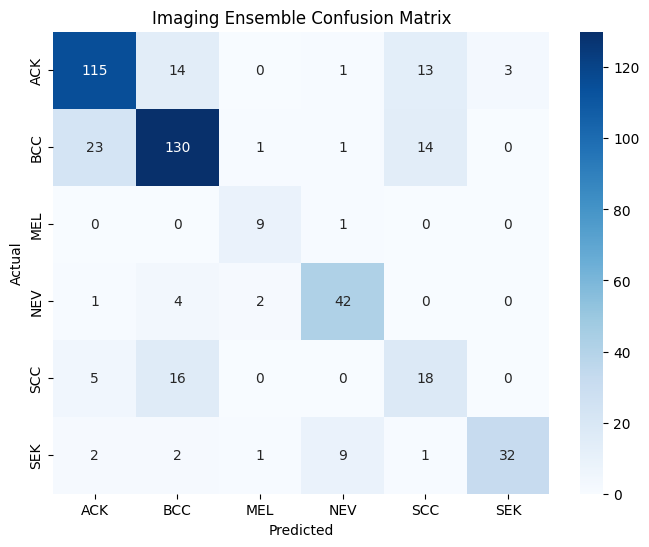

Saved image_ensemble_test_probs.npy and image_ensemble_test_preds.npy


In [ ]:
import os, math, warnings, time
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import tensorflow as tf

#from transformers import TFViTModel


from tensorflow.keras import layers, models, callbacks, optimizers

from tensorflow.keras.applications import ResNet50V2, DenseNet121
try:
    from tensorflow.keras.applications import efficientnet_v2
    EfficientNetV2B0 = efficientnet_v2.EfficientNetV2B0
except Exception:
    EfficientNetV2B0 = None

try:
    from tensorflow.keras.applications import efficientnet
    EfficientNetB3 = efficientnet.EfficientNetB3
    from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess
except Exception:
    EfficientNetB3 = None
    effnet_preprocess = None

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, roc_auc_score, f1_score, matthews_corrcoef
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns

print("TensorFlow:", tf.__version__)

# ----------------- CONFIG -----------------
BASE_PATH = "/content/drive/MyDrive/PAD-UFES-20"
META_PATH = os.path.join(BASE_PATH, "metadata.csv")
IMG_FOLDERS = [
    os.path.join(BASE_PATH, "imgs_part_1", "imgs_part_1"),
    os.path.join(BASE_PATH, "imgs_part_2", "imgs_part_2"),
    os.path.join(BASE_PATH, "imgs_part_3", "imgs_part_3"),
]
BATCH_SIZE = 24
EPOCHS_HEAD = 15
EPOCHS_FINE = 15
RANDOM_STATE = 42
TTA_STEPS = 6
MODELS_TO_RUN = ["resnet50v2", "densenet121", "effnetb3", "effv2b0", "vit_b16"]
# ------------------------------------------


# ---------- UTILITIES ----------
def map_image_paths(meta_df):
    meta_df = meta_df.copy()
    meta_df["constructed_name"] = meta_df["img_id"].astype(str).str.strip()
    import glob
    all_imgs = []
    for f in IMG_FOLDERS:
        all_imgs.extend(glob.glob(os.path.join(f, "*.png")))
    image_dict = {os.path.basename(p): p for p in all_imgs}
    meta_df["image_path"] = meta_df["constructed_name"].map(image_dict)
    return meta_df

def make_dataset(paths, labels, img_size, preprocess_fn=None, augment=False, batch_size=32):
    AUTOTUNE = tf.data.AUTOTUNE

    def _load_image(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_png(img, channels=3)
        img = tf.image.resize(img, img_size)
        img = tf.cast(img, tf.float32)
        if preprocess_fn is not None:
            img = preprocess_fn(img)
        else:
            img = img / 255.0
        return img, label

    def _augment(img, label):
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_flip_up_down(img)
        img = tf.image.random_brightness(img, max_delta=0.12)
        img = tf.image.random_contrast(img, 0.8, 1.2)
        img = tf.image.random_saturation(img, 0.8, 1.2)
        return img, label

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(_load_image, num_parallel_calls=AUTOTUNE)
    if augment:
        ds = ds.map(_augment, num_parallel_calls=AUTOTUNE)
        ds = ds.shuffle(2048)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds



def build_vit(img_size, n_classes):
    patch_size = 16
    num_patches = (img_size[0] // patch_size) ** 2
    embed_dim = 512          # ViT-B
    num_heads = 8
    transformer_layers = 8
    mlp_dim = 2048

    inputs = layers.Input(shape=(*img_size, 3))

    # Patch extraction + embedding
    x = PatchExtract(patch_size)(inputs)
    x = PatchEmbedding(num_patches, embed_dim)(x)

    # Transformer blocks
    for _ in range(transformer_layers):
        x1 = layers.LayerNormalization(epsilon=1e-6)(x)
        attention = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim
        )(x1, x1)
        x2 = layers.Add()([attention, x])

        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
        mlp = layers.Dense(mlp_dim, activation="gelu")(x3)
        mlp = layers.Dense(embed_dim)(mlp)

        x = layers.Add()([mlp, x2])

    # Classification head
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(n_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs)
    return model


class PatchExtract(layers.Layer):
    def __init__(self, patch_size):
        super().__init__()
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )
        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches


class PatchEmbedding(layers.Layer):
    def __init__(self, num_patches, embed_dim):
        super().__init__()
        self.num_patches = num_patches
        self.projection = layers.Dense(embed_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches, output_dim=embed_dim
        )

    def call(self, x):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        x = self.projection(x)
        return x + self.position_embedding(positions)



def build_backbone(name, img_size, n_classes):
    inp = layers.Input(shape=(*img_size, 3))

    if name == "resnet50v2":
        base = ResNet50V2(weights="imagenet", include_top=False, input_tensor=inp, pooling="avg")
    elif name == "densenet121":
        base = DenseNet121(weights="imagenet", include_top=False, input_tensor=inp, pooling="avg")
    elif name == "effnetb3" and EfficientNetB3 is not None:
        base = EfficientNetB3(weights="imagenet", include_top=False, input_tensor=inp, pooling="avg")
    elif name == "effv2b0" and EfficientNetV2B0 is not None:
        base = EfficientNetV2B0(weights="imagenet", include_top=False, input_tensor=inp, pooling="avg")
    elif name == "vit_b16":
      return build_vit(img_size, n_classes)


    else:
        raise ValueError(f"Backbone {name} not available.")

    for layer in base.layers:
        layer.trainable = False

    x = base.output
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(n_classes, activation="softmax")(x)
    model = models.Model(inputs=base.input, outputs=out)
    return model

def train_and_finetune(model, name, train_ds, val_ds, class_weight):

    import glob

    print(f"\nChecking for saved checkpoints for {name}...")

    ckpt_dir = "/content/drive/MyDrive/checkpoints"
    pattern = f"{ckpt_dir}/{name}_epoch_*.keras"
    files = sorted(glob.glob(pattern))

    if len(files) > 0:
        last_ckpt = files[-1]
        print(f"Resuming from checkpoint: {last_ckpt}")

        last_epoch = int(last_ckpt.split("_epoch_")[1].split(".")[0])
        initial_epoch = last_epoch
    else:
        print("No checkpoint found — training from epoch 0")
        initial_epoch = 0

    total_epochs = EPOCHS_HEAD + EPOCHS_FINE

    # ✅ SKIP BEFORE loading weights
    if initial_epoch >= total_epochs:
      print(f"{name} already fully trained — loading weights and skipping training.")
      model.load_weights(last_ckpt)
      return model


    # load weights ONLY when needed
    if len(files) > 0:
        model.load_weights(last_ckpt)

    # callbacks
    ckpt = callbacks.ModelCheckpoint(
        filepath=f"/content/drive/MyDrive/checkpoints/{name}_epoch_{{epoch:02d}}.keras",
        save_best_only=False,
        save_weights_only=False,
        monitor="val_accuracy",
        verbose=1
    )

    es = callbacks.EarlyStopping(
        monitor="val_accuracy", patience=4,
        restore_best_weights=True, verbose=1
    )

    rlr = callbacks.ReduceLROnPlateau(
        monitor="val_loss", patience=3,
        factor=0.5, verbose=1
    )

    loss = tf.keras.losses.SparseCategoricalCrossentropy()

    # -------- Phase 1: head --------
    if initial_epoch < EPOCHS_HEAD:
        print(f"Training head from epoch {initial_epoch} to {EPOCHS_HEAD}")

        model.compile(
            optimizer=optimizers.Adam(1e-3),
            loss=loss,
            metrics=["accuracy"]
        )

        model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=EPOCHS_HEAD,
            initial_epoch=initial_epoch,
            class_weight=class_weight,
            callbacks=[ckpt, es, rlr],
            verbose=1
        )

        initial_epoch = EPOCHS_HEAD

    # -------- Phase 2: fine-tune --------
    print(f"Fine-tuning last layers from epoch {initial_epoch} to {total_epochs}")

    for layer in model.layers[-80:]:
        layer.trainable = True

    model.compile(
        optimizer=optimizers.Adam(1e-4),
        loss=loss,
        metrics=["accuracy"]
    )

    model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=total_epochs,
        initial_epoch=initial_epoch,
        class_weight=class_weight,
        callbacks=[ckpt, es, rlr],
        verbose=1
    )

    return model



def predict_with_tta(model, paths, img_size, preprocess_fn=None, tta_steps=4, batch_size=32):
    AUTOTUNE = tf.data.AUTOTUNE
    probs = None
    for i in range(max(1, tta_steps)):
        def _load(path):
            img = tf.io.read_file(path)
            img = tf.image.decode_png(img, channels=3)
            img = tf.image.resize(img, img_size)
            img = tf.cast(img, tf.float32)
            if preprocess_fn is not None:
                img = preprocess_fn(img)
            else:
                img = img / 255.0
            if i > 0:
                img = tf.image.random_flip_left_right(img)
            return img

        ds = tf.data.Dataset.from_tensor_slices(paths)
        ds = ds.map(lambda p: _load(p), num_parallel_calls=AUTOTUNE)
        ds = ds.batch(batch_size).prefetch(AUTOTUNE)
        p = model.predict(ds, verbose=0)
        probs = p if probs is None else probs + p
    probs /= max(1, tta_steps)
    return probs


# ---------- LOAD META + LABEL ENCODE ----------
df_meta = pd.read_csv(META_PATH)
df_meta = map_image_paths(df_meta)
df_meta = df_meta.dropna(subset=["image_path", "diagnostic"]).reset_index(drop=True)

le = LabelEncoder()
df_meta["label"] = le.fit_transform(df_meta["diagnostic"])
class_names = list(le.classes_)
n_classes = len(class_names)
print("Classes:", class_names)

# single, consistent split (use this also for tabular if you want fusion)
train_df, test_df = train_test_split(
    df_meta,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df_meta["label"]
)
print("Train/Test:", len(train_df), len(test_df))

train_sub_df, val_df = train_test_split(
    train_df,
    test_size=0.12,
    random_state=RANDOM_STATE,
    stratify=train_df["label"]
)

train_paths = train_sub_df["image_path"].values
train_labels = train_sub_df["label"].values
val_paths = val_df["image_path"].values
val_labels = val_df["label"].values
test_paths = test_df["image_path"].values
test_labels = test_df["label"].values

# class weights
cw = compute_class_weight(class_weight="balanced",
                          classes=np.unique(train_labels),
                          y=train_labels)
class_weight_dict = {i: float(w) for i, w in enumerate(cw)}
print("Class weights:", class_weight_dict)

# ---------- LOOP OVER MODELS ----------
available_models = {
    "resnet50v2": True,
    "densenet121": True,
    "effnetb3": EfficientNetB3 is not None,
    "effv2b0": EfficientNetV2B0 is not None,
    "vit_b16": True
}
models_to_run = [m for m in MODELS_TO_RUN if available_models.get(m, False)]
print("Will run:", models_to_run)

preds_info = {}

for mname in models_to_run:
    print(f"\n\n=== MODEL: {mname} ===")
    if mname in ["effnetb3", "effv2b0"]:
      img_size = (300, 300)
      preprocess_fn = effnet_preprocess
      batch = 8
    elif mname == "vit_b16":
      img_size = (224, 224)
      preprocess_fn = None
      batch = 4
    else:
      img_size = (224, 224)
      preprocess_fn = None
      batch = BATCH_SIZE

    train_ds = make_dataset(train_paths, train_labels, img_size,
                            preprocess_fn=preprocess_fn, augment=True,
                            batch_size=batch)
    val_ds = make_dataset(val_paths, val_labels, img_size,
                          preprocess_fn=preprocess_fn, augment=False,
                          batch_size=batch)

    model = build_backbone(mname, img_size, n_classes)
    model = train_and_finetune(model, mname, train_ds, val_ds, class_weight_dict)

    # TTA predictions on test set
    probs = predict_with_tta(model, test_paths, img_size,
                             preprocess_fn=preprocess_fn,
                             tta_steps=TTA_STEPS,
                             batch_size=BATCH_SIZE)
    preds_info[mname] = {"probs": probs}
    preds_info[mname]["acc"] = accuracy_score(test_labels, np.argmax(probs, axis=1)) # can skip not necessary
    print(f"{mname} Test Accuracy: {preds_info[mname]['acc']:.4f}") # can skip, not necessary


# ---------- ENSEMBLE ----------
print("\n--- WEIGHTED ENSEMBLE ---")
weights = {"resnet50v2": 0.25, "densenet121": 0.20, "effnetb3": 0.20, "effv2b0": 0.15, "vit_b16": 0.20}

# start from zeros
any_model = next(iter(preds_info.values()))
all_probs = np.zeros_like(any_model["probs"], dtype=np.float32)

for name, info in preds_info.items():
    w = weights.get(name, 1.0)
    all_probs += info["probs"] * w

all_probs /= sum(weights[n] for n in preds_info.keys())

ens_preds = np.argmax(all_probs, axis=1)

acc = accuracy_score(test_labels, ens_preds)
bal = balanced_accuracy_score(test_labels, ens_preds)
auc = roc_auc_score(pd.get_dummies(test_labels), all_probs,
                    average="macro", multi_class="ovr")
f1 = f1_score(test_labels, ens_preds, average="macro")
mcc = matthews_corrcoef(test_labels, ens_preds)

print("\nENSEMBLE RESULTS:")
print(f"Accuracy         : {acc:.4f}")
print(f"Balanced Accuracy: {bal:.4f}")
print(f"AUROC (macro)    : {auc:.4f}")
print(f"F1 (macro)       : {f1:.4f}")
print(f"MCC              : {mcc:.4f}")

print("\nClassification Report:")
print(classification_report(test_labels, ens_preds, target_names=class_names, zero_division=0))

cm = confusion_matrix(test_labels, ens_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.title("Imaging Ensemble Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

np.save("/content/drive/MyDrive/checkpoints/image_ensemble_test_probs.npy", all_probs)
np.save("/content/drive/MyDrive/checkpoints/image_ensemble_test_preds.npy", ens_preds)
print("Saved image_ensemble_test_probs.npy and image_ensemble_test_preds.npy")



In [ ]:
DRIVE_PATH = "/content/drive/MyDrive/final_results"

import os
os.makedirs(DRIVE_PATH, exist_ok=True)


Tabular probs shape: (460, 6)
Image probs shape  : (460, 6)
Labels shape       : (460,)

⭐ Best alpha (tabular weight): 0.30000000000000004
Balanced Accuracy at best alpha: 0.8342

===== FINAL LATE FUSION RESULTS =====
Best alpha (tabular weight) : 0.30
Accuracy                    : 0.8652
Balanced Accuracy           : 0.8342
AUROC (macro)               : 0.9690
F1-score (macro)            : 0.8353
MCC                         : 0.8161

📊 Classification Report (Late Fusion):
              precision    recall  f1-score   support

         ACK       0.89      0.92      0.91       146
         BCC       0.87      0.89      0.88       169
         MEL       0.82      0.90      0.86        10
         NEV       0.82      0.92      0.87        49
         SCC       0.73      0.62      0.67        39
         SEK       0.92      0.77      0.84        47

    accuracy                           0.87       460
   macro avg       0.84      0.83      0.84       460
weighted avg       0.86      0.87

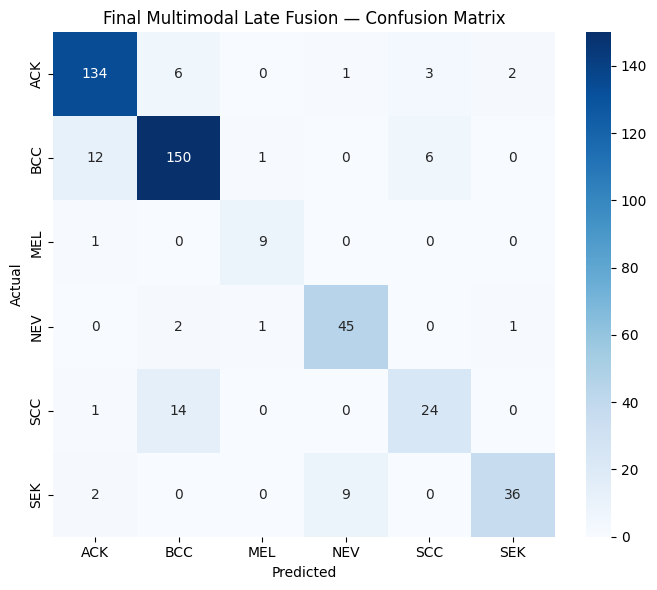


 Saved fusion_final_predictions.npy and fusion_final_probabilities.npy


In [ ]:
#LATE FUSION
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    classification_report,
    confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns

# ============================
# 1. Load saved probabilities
# ============================

tabular_probs = np.load("/content/drive/MyDrive/checkpoints/tabular_test_probs.npy")        # shape: (460, 6)
y_test = np.load("/content/drive/MyDrive/checkpoints/tabular_test_labels.npy")              # shape: (460,)
image_probs = np.load("/content/drive/MyDrive/checkpoints/image_ensemble_test_probs.npy")   # shape: (460, 6)

print("Tabular probs shape:", tabular_probs.shape)
print("Image probs shape  :", image_probs.shape)
print("Labels shape       :", y_test.shape)

# Sanity check: same number of samples
assert tabular_probs.shape == image_probs.shape, "Shapes of tabular and image probs do not match!"
assert tabular_probs.shape[0] == y_test.shape[0], "Number of samples in probs and labels do not match!"

# =======================================
# 2. Search for best fusion weight alpha
# =======================================

alphas = np.arange(0.0, 1.05, 0.05)  # 0.00, 0.05, ..., 1.00

results = []
best_alpha = None
best_bal_acc = -1.0
best_fused_probs = None

for alpha in alphas:
    fused_probs = alpha * tabular_probs + (1.0 - alpha) * image_probs
    preds = np.argmax(fused_probs, axis=1)

    acc = accuracy_score(y_test, preds)
    bal = balanced_accuracy_score(y_test, preds)
    f1  = f1_score(y_test, preds, average="macro")
    auc = roc_auc_score(
        np.eye(fused_probs.shape[1])[y_test],  # one-hot labels
        fused_probs,
        multi_class="ovr",
        average="macro"
    )
    mcc = matthews_corrcoef(y_test, preds)

    results.append((alpha, acc, bal, auc, f1, mcc))

    if bal > best_bal_acc:
        best_bal_acc = bal
        best_alpha = alpha
        best_fused_probs = fused_probs.copy()

print("\n⭐ Best alpha (tabular weight):", best_alpha)
print(f"Balanced Accuracy at best alpha: {best_bal_acc:.4f}")

# =======================================
# 3. Final evaluation with best alpha
# =======================================

final_probs = best_fused_probs
final_preds = np.argmax(final_probs, axis=1)

final_acc  = accuracy_score(y_test, final_preds)
final_bal  = balanced_accuracy_score(y_test, final_preds)
final_f1   = f1_score(y_test, final_preds, average="macro")
final_auc  = roc_auc_score(
    np.eye(final_probs.shape[1])[y_test],
    final_probs,
    multi_class="ovr",
    average="macro"
)
final_mcc  = matthews_corrcoef(y_test, final_preds)

print("\n===== FINAL LATE FUSION RESULTS =====")
print(f"Best alpha (tabular weight) : {best_alpha:.2f}")
print(f"Accuracy                    : {final_acc:.4f}")
print(f"Balanced Accuracy           : {final_bal:.4f}")
print(f"AUROC (macro)               : {final_auc:.4f}")
print(f"F1-score (macro)            : {final_f1:.4f}")
print(f"MCC                         : {final_mcc:.4f}")

# If y_le (LabelEncoder from tabular model) exists, use class names; otherwise use generic
try:
    class_names = list(y_le.classes_)
except NameError:
    class_names = [f"Class {i}" for i in range(final_probs.shape[1])]

print("\n📊 Classification Report (Late Fusion):")
print(classification_report(y_test, final_preds, target_names=class_names, zero_division=0))

# Confusion matrix
cm = confusion_matrix(y_test, final_preds)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Final Multimodal Late Fusion — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Optional: save for later
np.save(os.path.join(DRIVE_PATH, "fusion_final_predictions.npy"), final_preds)
np.save(os.path.join(DRIVE_PATH, "fusion_final_probabilities.npy"), final_probs)

print("\n Saved fusion_final_predictions.npy and fusion_final_probabilities.npy")


In [ ]:
save_path = "/content/drive/MyDrive/Explainability_results"
import os
os.makedirs(save_path, exist_ok=True)




In [ ]:
test_df.columns
test_df[["img_id", "diagnostic", "image_path"]]

#len(test_df)





,img_id,diagnostic,image_path
11,PAT_967_1827_247.png,BCC,/content/drive/MyDrive/PAD-UFES-20/imgs_part_2...
719,PAT_905_1721_327.png,BCC,/content/drive/MyDrive/PAD-UFES-20/imgs_part_2...
305,PAT_1661_2956_357.png,ACK,/content/drive/MyDrive/PAD-UFES-20/imgs_part_3...
2034,PAT_1107_427_352.png,NEV,/content/drive/MyDrive/PAD-UFES-20/imgs_part_3...
2098,PAT_2077_4463_77.png,ACK,/content/drive/MyDrive/PAD-UFES-20/imgs_part_3...
...,...,...,...
331,PAT_1922_3848_451.png,SEK,/content/drive/MyDrive/PAD-UFES-20/imgs_part_3...
1747,PAT_1468_3656_337.png,ACK,/content/drive/MyDrive/PAD-UFES-20/imgs_part_3...
1506,PAT_406_809_581.png,BCC,/content/drive/MyDrive/PAD-UFES-20/imgs_part_1...
1093,PAT_1573_2497_736.png,ACK,/content/drive/MyDrive/PAD-UFES-20/imgs_part_3...


Image ID    : PAT_1468_3656_337.png
True label  : ACK
Image path  : /content/drive/MyDrive/PAD-UFES-20/imgs_part_3/imgs_part_3/PAT_1468_3656_337.png


(np.float64(-0.5), np.float64(299.5), np.float64(299.5), np.float64(-0.5))

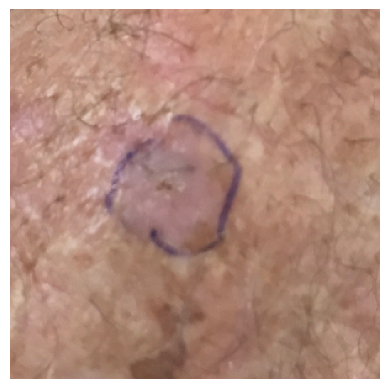

In [ ]:
# View a random test image
row = test_df.sample(1).iloc[0]

print("Image ID    :", row["img_id"])
print("True label  :", row["diagnostic"])
print("Image path  :", row["image_path"])

img = tf.keras.preprocessing.image.load_img(row["image_path"], target_size=(300,300))
plt.imshow(img)
plt.axis("off")

In [ ]:
"""Find test images of a specific class
Example: all MEL images in test set"""

test_df[test_df["diagnostic"] == "MEL"][["img_id", "image_path"]]


,img_id,image_path
1481,PAT_680_1289_585.png,/content/drive/MyDrive/PAD-UFES-20/imgs_part_2...
1844,PAT_333_702_840.png,/content/drive/MyDrive/PAD-UFES-20/imgs_part_1...
1575,PAT_611_1158_156.png,/content/drive/MyDrive/PAD-UFES-20/imgs_part_2...
480,PAT_801_1518_78.png,/content/drive/MyDrive/PAD-UFES-20/imgs_part_2...
2015,PAT_949_1802_582.png,/content/drive/MyDrive/PAD-UFES-20/imgs_part_2...
1537,PAT_320_681_724.png,/content/drive/MyDrive/PAD-UFES-20/imgs_part_1...
830,PAT_884_1683_538.png,/content/drive/MyDrive/PAD-UFES-20/imgs_part_2...
542,PAT_746_1407_708.png,/content/drive/MyDrive/PAD-UFES-20/imgs_part_2...
529,PAT_995_1867_165.png,/content/drive/MyDrive/PAD-UFES-20/imgs_part_2...
86,PAT_995_1867_5.png,/content/drive/MyDrive/PAD-UFES-20/imgs_part_2...


Last conv layer: top_conv
1/1 ━━━━━━━━━━━━━━━━━━━━ 18s 18s/step
ACK: 0.0092
BCC: 0.0010
MEL: 0.0001
NEV: 0.0002
SCC: 0.0004
SEK: 0.9892
Actual class   : SEK
Predicted class: SEK
Confidence: 0.98915404


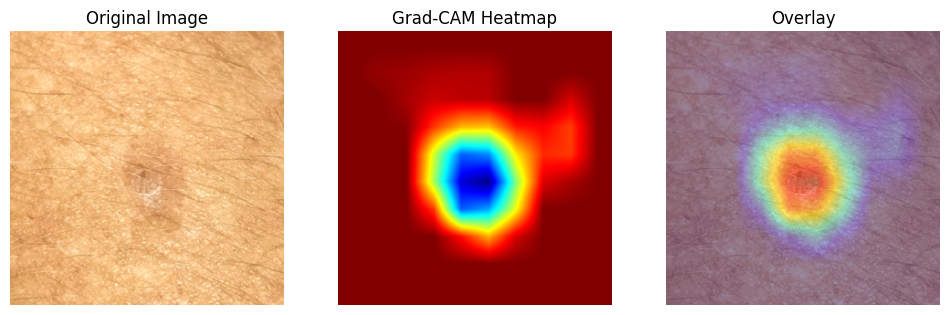

True

In [ ]:
# EXPLAINABILITY – GRAD-CAM

import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Load best trained image model
model = tf.keras.models.load_model(
    "/content/drive/MyDrive/checkpoints/effnetb3_epoch_30.keras",
    compile=False
)
# model.summary()

for layer in model.layers[::-1]:
    if "conv" in layer.name:
        print("Last conv layer:",layer.name)
        last_conv_layer_name = layer.name
        break

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap) + 1e-8

    return heatmap.numpy(), int(class_idx)

from tensorflow.keras.applications.efficientnet import preprocess_input

def preprocess_image(img_path, img_size=(300,300)):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=img_size)
    img = tf.keras.preprocessing.image.img_to_array(img)
    img = np.expand_dims(img, axis=0)
    img = preprocess_input(img)   # ✅ CORRECT
    return img


img_path = test_df.iloc[77]["image_path"] # any test image
img_array = preprocess_image(img_path)

actual_label = test_df.iloc[77]["diagnostic"]
actual_class = actual_label

pred = model.predict(img_array)
probs = pred[0]
for i, cls in enumerate(class_names):
    print(f"{cls}: {probs[i]:.4f}")

pred_class = np.argmax(pred)

print("Actual class   :", actual_class)
print("Predicted class:", class_names[pred_class])
print("Confidence:", np.max(pred))


heatmap, pred_class = make_gradcam_heatmap(
    img_array, model, last_conv_layer_name
)

img = cv2.imread(img_path)
img = cv2.resize(img, (300,300))
heatmap = cv2.resize(heatmap, (300,300))

heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

superimposed = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Original Image")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Grad-CAM Heatmap")
plt.imshow(heatmap)
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Overlay")
plt.imshow(cv2.cvtColor(superimposed, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.show()

save_path = "/content/drive/MyDrive/Explainability_results/effnetb3_gradcam.png"
os.makedirs(os.path.dirname(save_path), exist_ok=True)
cv2.imwrite(save_path, superimposed)


